In [1]:
import pandas as pd
import numpy as np
import os
import re
import string
import nltk
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_linear_schedule_with_warmup, BertModel, DataCollatorWithPadding
from torch.utils.data import DataLoader, Dataset, random_split
import torch
from tqdm import tqdm
import logging
import torch.nn as nn
import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from transformers import LongformerForSequenceClassification
from transformers import LongformerTokenizer

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Ensure necessary NLTK resources are downloaded
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_tweet(text, stop_words = True, lemma = True):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags (keeping the text)
    text = re.sub(r'#', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    # text = re.sub(r'\d+', '', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    if (stop_words == True):
        # Remove stop words
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]

    if (lemma == True):
        # Lemmatization
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back to string
    text = ' '.join(tokens)

    return text

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [4]:
def clean_text_first_pass(text):
    """
    Clean the text by removing irrelevant information such as newlines, underscores, extra spaces,
    repeating "=" signs, specific phrases, and leading punctuation marks.
    """
    # Remove newline characters
    text = text.replace('\n', ' ')

    # Remove underscores
    text = text.replace('_', '')

    # Remove repeating "=" signs
    text = re.sub(r'=+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove leading punctuation marks
    text = re.sub(r'^[!@#$%^&*()_+\-=\[\]{};:"\\|,.<>/?~`]+', '', text)

    # Remove specific phrases
    phrases_to_remove = [
        'Name:', 'Unit No:', 'Admission Date:', 'Discharge Date:', 'Date of Birth:', 'Sex: F', 'Sex: M'
    ]
    for phrase in phrases_to_remove:
        text = text.replace(phrase, '')

    # Remove leading spaces
    text = text.lstrip()

    # Convert to lowercase
    text = text.lower()

    # Removes punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove leading spaces
    text = text.lstrip()
    return text

In [5]:
def clean_text_first_pass_simple(text):
    """
    Clean the text by removing irrelevant information such as newlines, underscores, extra spaces,
    repeating "=" signs, specific phrases, and leading punctuation marks.
    """
    # Remove newline characters
    text = text.replace('\n', ' ')

    # Remove underscores
    text = text.replace('_', '')

    # Remove repeating "=" signs
    text = re.sub(r'=+', '', text)

    # Remove extra spaces
    # text = re.sub(r'\s+', ' ', text).strip()

    # Remove leading punctuation marks
    # text = re.sub(r'^[!@#$%^&*()_+\-=\[\]{};:"\\|,.<>/?~`]+', '', text)

    # Remove specific phrases
    phrases_to_remove = [
        'Name:', 'Unit No:', 'Admission Date:', 'Discharge Date:', 'Date of Birth:', 'Sex:   F', 'Sex:   M'
    ]
    for phrase in phrases_to_remove:
        text = text.replace(phrase, '')

    # Remove leading spaces
    # text = text.lstrip()

    # Convert to lowercase
    # text = text.lower()

    # Removes punctuation
    # text = re.sub(r'[^\w\s]', '', text)

    # Remove leading spaces
    # text = text.lstrip()
    return text

In [6]:
df_annotations = pd.read_csv('/content/drive/My Drive/EHR_PROJ/DATA/annotations.csv')

In [7]:
mimic = pd.read_csv('/content/drive/My Drive/EHR_PROJ/DATA/mimic-iv-note/2.2/note/discharge.csv')

In [8]:
mimic_annotated = pd.merge(mimic, df_annotations, left_on = 'note_id', right_on = 'encounter_note_id', how = 'inner')

In [9]:
mimic_annotated['clean_text'] = mimic_annotated['text'].apply(clean_text_first_pass_simple)

In [10]:
columns_to_keep = ['note_id', 'subject_id', 'label', 'clean_text', 'text']
mimic_annotated_final = mimic_annotated[columns_to_keep]

In [11]:
# prompt: Count number of words in clean_text

mimic_annotated_final['word_count'] = mimic_annotated_final['clean_text'].apply(lambda x: len(x.split()))
print(mimic_annotated_final['word_count'].describe())


count    5043.000000
mean     1912.786635
std       747.937092
min       388.000000
25%      1403.000000
50%      1792.000000
75%      2287.500000
max      6809.000000
Name: word_count, dtype: float64


<ipython-input-11-3578d2c6b3e7>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mimic_annotated_final['word_count'] = mimic_annotated_final['clean_text'].apply(lambda x: len(x.split()))


In [12]:
mimic_annotated_final['text_word_count'] = mimic_annotated_final['text'].apply(lambda x: len(x.split()))
print(mimic_annotated_final['text_word_count'].describe())

count    5043.000000
mean     1982.993853
std       767.942801
min       419.000000
25%      1462.500000
50%      1858.000000
75%      2367.000000
max      6930.000000
Name: text_word_count, dtype: float64


<ipython-input-12-ef2656ee9071>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mimic_annotated_final['text_word_count'] = mimic_annotated_final['text'].apply(lambda x: len(x.split()))


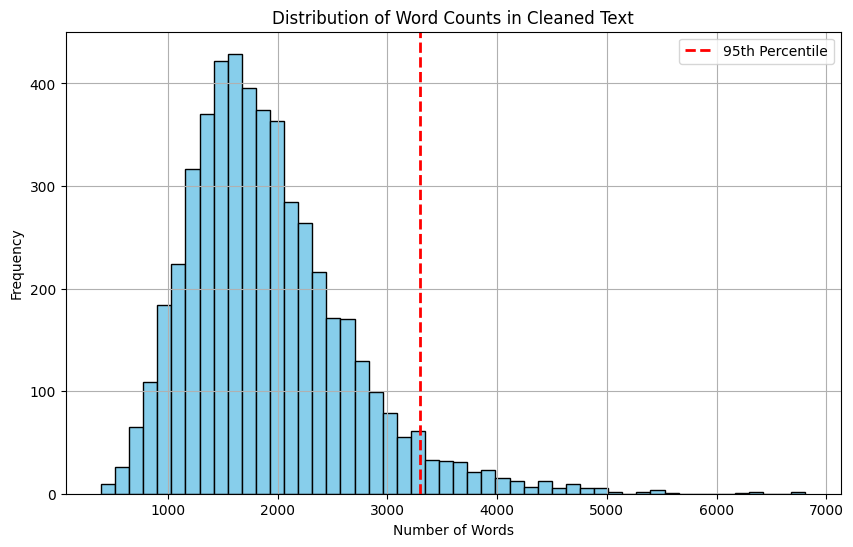

In [13]:
import matplotlib.pyplot as plt
# Plot number of words in clean_text. Mark 90% quantile

# Calculate the 90th percentile for word count
quantile_90 = mimic_annotated_final['word_count'].quantile(0.95)

# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
plt.hist(mimic_annotated_final['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(quantile_90, color='red', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts in Cleaned Text')
plt.legend()
plt.grid(True)
plt.show()


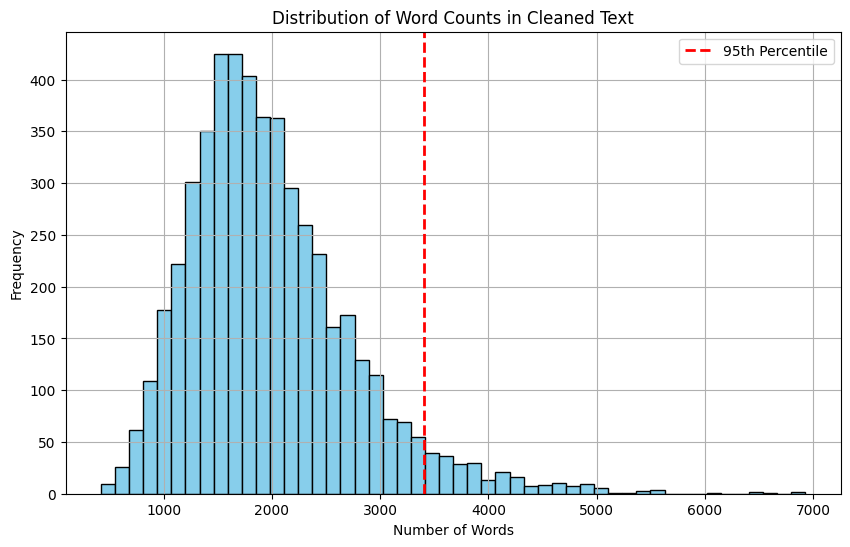

In [14]:
# Plot number of words in clean_text. Mark 90% quantile

# Calculate the 90th percentile for word count
quantile_90 = mimic_annotated_final['text_word_count'].quantile(0.95)

# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
plt.hist(mimic_annotated_final['text_word_count'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(quantile_90, color='red', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts in Cleaned Text')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
mimic_annotated_final['label'].value_counts()

,count
label,
negative,2114
positive,648
exclude,611
disbelief,609
neutral,535
difficult,526


In [16]:
mimic_annotated_final

,note_id,subject_id,label,clean_text,text,word_count,text_word_count
0,10000980-DS-20,10000980,negative,...,\nName: ___ Unit No: ___\n \nAdmi...,1922,1984
1,10004322-DS-21,10004322,disbelief,...,\nName: ___ Unit No: ___\n...,1267,1324
2,10004457-DS-11,10004457,positive,. ...,\nName: ___. Unit No: ___\n \n...,1740,1811
3,10005368-DS-10,10005368,negative,...,\nName: ___ Unit No: __...,1760,1861
4,10005749-DS-17,10005749,difficult,...,\nName: ___ Unit No: _...,1584,1644
...,...,...,...,...,...,...,...
5038,19993214-DS-11,19993214,negative,. ...,\nName: ___. Unit No: ___\n \...,2170,2248
5039,19993214-DS-13,19993214,negative,. ...,\nName: ___. Unit No: ___\n \...,1709,1775
5040,19994592-DS-14,19994592,neutral,...,\nName: ___ Unit No: ___\n ...,2692,2811
5041,19997293-DS-9,19997293,negative,...,\nName: ___ Unit No: _...,1979,2045


In [17]:
# prompt: check duplicates under text column

duplicate_rows = mimic_annotated_final[mimic_annotated_final.duplicated(subset=['text'], keep=False)]

print("Duplicate Rows based on 'text' column:")
duplicate_rows

Duplicate Rows based on 'text' column:


,note_id,subject_id,label,clean_text,text,word_count,text_word_count
19,10034049-DS-19,10034049,difficult,...,\nName: ___ Unit No: ___\n \nAd...,3300,3430
20,10034049-DS-19,10034049,negative,...,\nName: ___ Unit No: ___\n \nAd...,3300,3430
21,10034049-DS-19,10034049,difficult,...,\nName: ___ Unit No: ___\n \nAd...,3300,3430
23,10038332-DS-18,10038332,negative,...,\nName: ___ Unit No: ___\n...,2911,2992
24,10038332-DS-18,10038332,neutral,...,\nName: ___ Unit No: ___\n...,2911,2992
...,...,...,...,...,...,...,...
4914,19759491-DS-34,19759491,disbelief,...,\nName: ___ Unit No: ___\n \...,3738,3831
4921,19764408-DS-47,19764408,negative,...,\nName: ___ Unit No: ___\...,2145,2212
4922,19764408-DS-47,19764408,negative,...,\nName: ___ Unit No: ___\...,2145,2212
5002,19920312-DS-4,19920312,positive,...,\nName: ___ Unit No: ___\...,2043,2090


In [18]:
# prompt: remove the duplicates and reset index

# Drop duplicates based on the 'text' column and keep the first occurrence
mimic_annotated_final = mimic_annotated_final.drop_duplicates(subset=['text'], keep='first')

# Reset the index of the DataFrame
mimic_annotated_final = mimic_annotated_final.reset_index(drop=True)

# Now mimic_annotated_final contains the data without duplicates and with a reset index.
mimic_annotated_final

,note_id,subject_id,label,clean_text,text,word_count,text_word_count
0,10000980-DS-20,10000980,negative,...,\nName: ___ Unit No: ___\n \nAdmi...,1922,1984
1,10004322-DS-21,10004322,disbelief,...,\nName: ___ Unit No: ___\n...,1267,1324
2,10004457-DS-11,10004457,positive,. ...,\nName: ___. Unit No: ___\n \n...,1740,1811
3,10005368-DS-10,10005368,negative,...,\nName: ___ Unit No: __...,1760,1861
4,10005749-DS-17,10005749,difficult,...,\nName: ___ Unit No: _...,1584,1644
...,...,...,...,...,...,...,...
4705,19993214-DS-11,19993214,negative,. ...,\nName: ___. Unit No: ___\n \...,2170,2248
4706,19993214-DS-13,19993214,negative,. ...,\nName: ___. Unit No: ___\n \...,1709,1775
4707,19994592-DS-14,19994592,neutral,...,\nName: ___ Unit No: ___\n ...,2692,2811
4708,19997293-DS-9,19997293,negative,...,\nName: ___ Unit No: _...,1979,2045


In [19]:
# Stigmatizing language mark as 1
def map_label(label):
    if label in ['difficult', 'disbelief', 'negative']:
        return 1
    elif label in ['exclude']:
        return 2
    else:
        return 0

In [20]:
mimic_annotated_final['labels_encoded'] = mimic_annotated_final['label'].apply(map_label)

In [21]:
mimic_annotated_final['labels_encoded'].value_counts()

,count
labels_encoded,
1,3003
0,1126
2,581


In [22]:
# Assuming mimic_annotated_final is your DataFrame from the previous code
# Calculate the percentage of label 1
percentage_label_1 = (mimic_annotated_final['labels_encoded'] == 1).sum() / len(mimic_annotated_final) * 100

print(f"Percentage of label 1: {percentage_label_1:.2f}%")

Percentage of label 1: 63.76%


In [23]:
# Assuming mimic_annotated_final is your DataFrame from the previous code
# Calculate the percentage of label 1
percentage_label_1 = (mimic_annotated_final['labels_encoded'] == 0).sum() / len(mimic_annotated_final) * 100

print(f"Percentage of label 0: {percentage_label_1:.2f}%")

Percentage of label 0: 23.91%


In [24]:
# Assuming mimic_annotated_final is your DataFrame from the previous code
# Calculate the percentage of label 1
percentage_label_1 = (mimic_annotated_final['labels_encoded'] == 2).sum() / len(mimic_annotated_final) * 100

print(f"Percentage of label 2: {percentage_label_1:.2f}%")

Percentage of label 2: 12.34%


In [25]:
df_binary = mimic_annotated_final[mimic_annotated_final['labels_encoded'].isin([0, 1])]
print(df_binary['labels_encoded'].value_counts())

labels_encoded
1    3003
0    1126
Name: count, dtype: int64


In [26]:
# Assuming mimic_annotated_final is your DataFrame from the previous code
# Calculate the percentage of label 1
percentage_label_1 = (df_binary['labels_encoded'] == 1).sum() / len(df_binary) * 100

print(f"Percentage of label 1: {percentage_label_1:.2f}%")

Percentage of label 1: 72.73%


In [27]:
# Assuming mimic_annotated_final is your DataFrame from the previous code
# Calculate the percentage of label 1
percentage_label_0 = (df_binary['labels_encoded'] == 0).sum() / len(df_binary) * 100

print(f"Percentage of label 0: {percentage_label_0:.2f}%")

Percentage of label 0: 27.27%


In [28]:
texts = mimic_annotated_final['text'].to_numpy()
labels = mimic_annotated_final['labels_encoded'].to_numpy()

# Split the data into training and validation sets (80% train, 20% val)
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, stratify=labels, random_state=42)

In [29]:
# Save train_texts, val_texts, train_labels, val_labels to DATA as csv

# Create DataFrames from the lists
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
val_df = pd.DataFrame({'text': val_texts, 'label': val_labels})

# Save the DataFrames to CSV files
train_df.to_csv('/content/drive/My Drive/EHR_PROJ/DATA/mimic_no_preprocess_multi_train.csv', index=False)
val_df.to_csv('/content/drive/My Drive/EHR_PROJ/DATA/mimic_no_preprocess_multi_val.csv', index=False)


In [30]:
train_df['label'].value_counts(normalize=True)

,proportion
label,
1,0.637473
0,0.239119
2,0.123408


In [31]:
val_df['label'].value_counts(normalize=True)

,proportion
label,
1,0.638004
0,0.238854
2,0.123142


In [32]:
texts = df_binary['text'].to_numpy()
labels = df_binary['labels_encoded'].to_numpy()

# Split the data into training and validation sets (80% train, 20% val)
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, stratify=labels, random_state=42)

In [33]:
# Save train_texts, val_texts, train_labels, val_labels to DATA as csv

# Create DataFrames from the lists
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
val_df = pd.DataFrame({'text': val_texts, 'label': val_labels})

# Save the DataFrames to CSV files
train_df.to_csv('/content/drive/My Drive/EHR_PROJ/DATA/mimic_no_preprocess_binary_train.csv', index=False)
val_df.to_csv('/content/drive/My Drive/EHR_PROJ/DATA/mimic_no_preprocess_binary_val.csv', index=False)


In [34]:
train_df['label'].value_counts(normalize=True)

,proportion
label,
1,0.727218
0,0.272782


In [35]:
val_df['label'].value_counts(normalize=True)

,proportion
label,
1,0.727603
0,0.272397
